# PAE Tutorial

### step-by-step instructions for training a probabilsitic autoencoder with this package

In [36]:
import sys
sys.path.append("../../PytorchPAE/")

# import this package 
from pytorch_pae import AE

In [37]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [39]:
# import pytorch
import torch

print(torch.__version__)

1.10.1+cu113


In [40]:
# from torchsummary import summary

In [41]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [42]:
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel
from scipy.stats import norm

t_min = -1  # Coordinate boundaries
t_max = 1
n_t = 64  # Number of pixels
counts_min = 2  # Minimum and maximum counts emitted by each PS
counts_max = 2
fwhm_psf = 0.5  # FWHM of Gaussian PSF

# Pixel binning
pixel_size = (t_max - t_min) / n_t
bins = np.linspace(t_min, t_max, n_t + 1)

# PSF stuff
sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

def simulate(plot=False, poiss_fluctuate=False):
    
    mu_iso = np.random.uniform(0, 10)
    
    mu_ps_iso = np.random.uniform(0, 200)
    n_ps_iso = np.random.poisson(mu_ps_iso)
    
    # Draw position of PSs and their counts
    z_x_iso = np.random.uniform(t_min, t_max, size=(2, n_ps_iso))
    z_c_iso = np.random.uniform(counts_min, counts_max, n_ps_iso)
    
    mu_ps_csp = np.random.uniform(0, 10)
    n_ps_csp = 0  # np.random.poisson(mu_ps_csp)
    
    # Draw position of PSs and their counts
    z_x_csp = norm.rvs(loc=0, scale=0.5, size=(2, n_ps_csp)) 
    z_c_csp = np.random.uniform(counts_min, counts_max, n_ps_csp)
    
    mu_iso_map = mu_iso * np.ones((n_t, n_t))

    if n_ps_iso > 0:
        mu_signal_iso = binned_statistic_2d(x=z_x_iso[0], y=z_x_iso[1], values=z_c_iso, statistic='sum', bins=bins).statistic
    else:
        mu_signal_iso = np.zeros_like(mu_iso_map)
        
    if n_ps_csp > 0:
        mu_signal_csp = binned_statistic_2d(x=z_x_csp[0], y=z_x_csp[1], values=z_c_csp, statistic='sum', bins=bins).statistic
    else:
        mu_signal_csp =  np.zeros_like(mu_iso_map)
        
    counts_binned = (mu_iso_map + convolve(mu_signal_iso, kernel) + convolve(mu_signal_csp, kernel))

    if poiss_fluctuate:
        counts_binned = np.random.poisson(counts_binned)

    if plot:
        plt.imshow(counts_binned)
    
    return mu_ps_iso, counts_binned

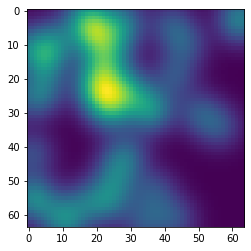

In [25]:
_, x = simulate(plot=True)

In [79]:
from tqdm.notebook import tqdm
simulations = [simulate() for _ in tqdm(range(10000))]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [80]:
from operator import itemgetter

x = list(map(itemgetter(1), simulations))
mu_ps_iso = list(map(itemgetter(0), simulations))

In [81]:
x = torch.Tensor(np.array(x)).unsqueeze(1)
y = torch.Tensor(np.array([mu_ps_iso])).T

In [82]:
x_std = x.std(axis=0)
x_mean = x.mean(axis=0)
x = (x - x_mean) / x_std

y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y = (y - y_mean) / y_std

In [83]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [84]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=8, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=8, shuffle=False)

In [56]:
# import torchvision
# import torchvision.transforms as transforms

# data_transform = transforms.Compose([
#                 transforms.ToTensor()
#         ])
# dataset = torchvision.datasets.MNIST('.', transform=data_transform, download=False)

# val_fraction = 0.1
# n_samples_val = int(val_fraction * len(dataset))

# dataset_train, dataset_val = random_split(dataset, [len(dataset) - n_samples_val, n_samples_val])
# train_loader = DataLoader(dataset_train, batch_size=64, num_workers=0
#                           , shuffle=True)
# val_loader = DataLoader(dataset_val, batch_size=64, num_workers=0, shuffle=False)

## Step 1: Choose your parameters

In [101]:
# ## data parameters
# dataset       = 'MNIST'
# loc           = '/global/cscratch1/sd/vboehm/Datasets'

# number of layers in networks
n_layers     = 3

## convolutional net specific parameters
# number of channels in each layer for convolutional neural net
out_channels = [16,32,64]
# kernel sizes in each layer for conv net
kernel_sizes = [7,3,3]
# scaling factor in max pooling layer 
scale_facs   = [1,1,1] 
# padding values in each conv layer
paddings     = [5,2,5]
# stride values in each conv layer
strides      = [2,1,1]
# whether tp apply a layer normalization after conv layer
layer_norm   = [True,True,True]
# whether to train elemntwise affine parameters for normalization layer 
affine       = True

## fully connected net specific parameters
# output size of each fully connected layer
out_sizes    = [1024,512,256]

## parameters that apply to both, fully connected and convolutional nets 
# dropout rate after each layer
dropout_rate = [0.,0.,0.]
# whether to Lipschitz regularize by bounding the spectral norm 
spec_norm    = True
# activation function after each layer
activations  = ['ReLU', 'ReLU','ReLU']
# whether to add a bias in each layer or not
bias         = [True, True, True]

## general parameters
# data dimensionality
dim          = '2D'
# latent space dimensionality
latent_dim   = 256

# number of channels in data
input_c      = 1 
# data dimensioality along one axis (only square data supported in 2D)
input_dim    = 64
# type of encoder and decoder network (either 'fc' or 'conv')
encoder_type = 'conv'
decoder_type = 'conv'

# if True, the output is fed through a sigmoid layer to bring data values into range [0,1]
final_sigmoid = False


## Training parameters
nepochs       = 30
batchsize     = 64
initial_lr    = 3e-4

optimizer     = 'Adam'
criterion     = 'MSELoss'

scheduler     = 'ExponentialLR'
scheduler_params = {'gamma':0.95}



In [102]:
general_params      = {'input_c': input_c, 'input_dim': input_dim, 'latent_dim': latent_dim, 'encoder_type': encoder_type, 'decoder_type': decoder_type, 'dim': dim}
conv_network_params = {'n_layers': n_layers, 'out_channels': out_channels, 'kernel_sizes': kernel_sizes, 'scale_facs': scale_facs, 'paddings': paddings,\
                       'strides': strides,'activations': activations, 'spec_norm': spec_norm, 'layer_norm': layer_norm,\
                       'affine': affine,'final_sigmoid': final_sigmoid, 'bias':bias}
fc_network_params   = {'n_layers': n_layers, 'out_sizes': out_sizes,'activations': activations, 'spec_norm': spec_norm, 'dropout_rate':dropout_rate, \
                       'layer_norm': layer_norm, 'affine': affine, 'final_sigmoid': final_sigmoid, 'bias':bias}

training_params     = {'batchsize': batchsize, 'initial_lr': initial_lr, 'optimizer': optimizer, 'criterion': criterion, \
                       'scheduler': scheduler, 'scheduler_params':scheduler_params}
# data_params         = {'dataset':dataset, 'loc': loc}

## Step 2: Set up and train the autoencoder

In [103]:
AE1 = AE.Autoencoder(general_params,train_loader, val_loader, conv_network_params, conv_network_params, training_params, device)

In [104]:
# if dim =='1D':
#     summary(AE1, (input_c,input_dim))
# else:
#     summary(AE1, (input_c, input_dim, input_dim))

In [105]:
train_loss, valid_loss = AE1.train(nepochs)

  3%|█▋                                                  | 1/30 [00:08<03:54,  8.09s/it]

epoch: 0, training loss: 1.0677e-01, validation loss: 7.2781e-04, learning rate: 2.8500e-04


  7%|███▍                                                | 2/30 [00:16<03:45,  8.06s/it]

epoch: 1, training loss: 1.9040e-03, validation loss: 3.5972e-03, learning rate: 2.7075e-04


 10%|█████▏                                              | 3/30 [00:24<03:41,  8.19s/it]

...

epoch: 27, training loss: 5.0164e-05, validation loss: 5.3066e-05, learning rate: 7.1348e-05


 97%|█████████████████████████████████████████████████▎ | 29/30 [03:56<00:08,  8.03s/it]

epoch: 28, training loss: 5.3494e-05, validation loss: 6.7997e-05, learning rate: 6.7781e-05


100%|███████████████████████████████████████████████████| 30/30 [04:04<00:00,  8.16s/it]

epoch: 29, training loss: 6.8893e-05, validation loss: 1.4374e-04, learning rate: 6.4392e-05


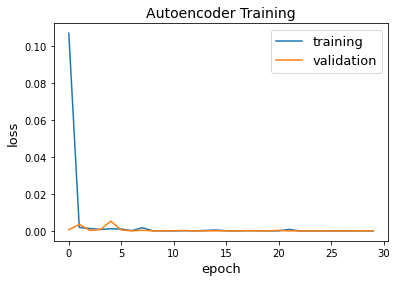

In [106]:
plt.figure()
plt.title('Autoencoder Training',fontsize=14)
plt.plot(train_loss, label='training')
plt.plot(valid_loss, label='validation')
plt.xlabel('epoch',fontsize=13)
plt.ylabel('loss',fontsize=13)
plt.legend(fontsize=13)
plt.show()

## Data reconstructions

In [107]:
# from pytorch_pae.data_loader import *

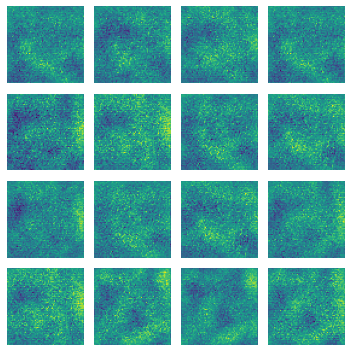

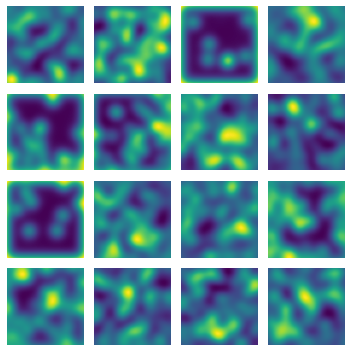

In [108]:
train_loader, valid_loader = train_loader, val_loader

data, _  = next(iter(train_loader))

recon = AE1.forward(data.to(device))

fig, ax = plt.subplots(4,4,figsize=(5,5))
ax = ax.flatten()
for ii in range(16):
    ax[ii].imshow(np.squeeze(recon[ii].cpu().detach().numpy()))
    ax[ii].axis('off')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(4,4,figsize=(5,5))
ax = ax.flatten()
for ii in range(16):
    ax[ii].imshow(np.squeeze(data[ii].cpu().detach().numpy()))
    ax[ii].axis('off')
plt.tight_layout()
plt.show()


In [36]:
torch.save(AE1, os.path.join('/global/cscratch1/sd/vboehm/Models/Tutorials', 'AE'))

## Step 3: Train the density estimator on the encoded data

In [37]:
# import density estimation module
from sinf import GIS

In [38]:
# load auutoencoder
AE1 = torch.load(os.path.join('/global/cscratch1/sd/vboehm/Models/Tutorials', 'AE'))

In [39]:
from pytorch_pae.data_loader import *

In [40]:
# encode data

train_loader, valid_loader = get_data(data_params['dataset'],data_params['loc'],-1, -1)

data, _  = next(iter(train_loader))
data     = data.to(device)

valid_data, _  = next(iter(valid_loader))
valid_data     = valid_data.to(device)

with torch.no_grad():
    encoded_train = AE1.encoder.forward(data)
    encoded_valid = AE1.encoder.forward(valid_data)

In [41]:
# train density estimator
gis = GIS.GIS(encoded_train, data_validate=encoded_valid, verbose=False)

In [42]:
torch.save(gis, os.path.join('/global/cscratch1/sd/vboehm/Models/Tutorials', 'GIS'))

## Density Estimation and Outlier Detection

In [43]:
logps       = gis.evaluate_density(encoded_train)
logps_valid = gis.evaluate_density(encoded_valid)

In [44]:
logps       = logps.cpu().detach().numpy()
logps_valid = logps_valid.cpu().detach().numpy()

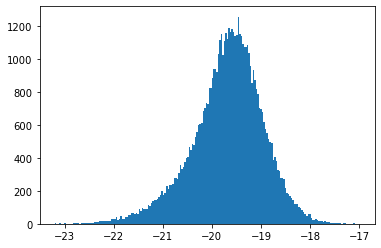

In [45]:
_       = plt.hist(logps,bins=200)

In [46]:
ranking = np.argsort(logps)

### Digits with lowest probability

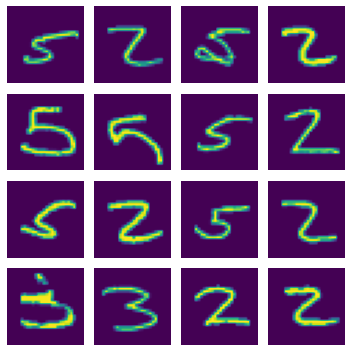

In [47]:
fig, ax = plt.subplots(4,4,figsize=(5,5))
ax = ax.flatten()
for ii in range(16):
    ax[ii].imshow(np.squeeze(data[ranking[ii]].cpu().detach().numpy()))
    ax[ii].axis('off')
plt.tight_layout()
plt.show()

## Data Generation

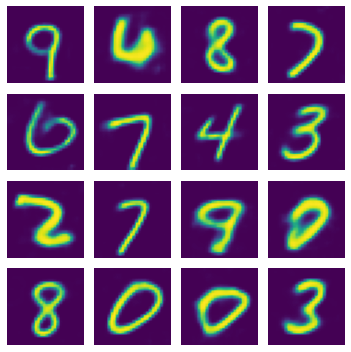

In [48]:
samples, _ = gis.sample(16)
with torch.no_grad():
    decoded_samples = AE1.decoder.forward(samples)

fig, ax = plt.subplots(4,4,figsize=(5,5))
ax = ax.flatten()
for ii in range(16):
    ax[ii].imshow(np.squeeze(decoded_samples[ii].cpu().detach().numpy()))
    ax[ii].axis('off')
plt.tight_layout()
plt.show()
